# A01 - Routing Strategy Comparison

## Objetivo
Comparar `ShortestHopCountRouting`, `LeastLossRouting` e
`HighestFidelityRouting` usando os dados reais e já persistidos da
campanha `C01_routing_strategy` (9 trials: 3 estratégias x 3 seeds, sobre
a topologia em diamante - ver `docs/campaign_architecture.md`). Este
notebook **não roda nenhuma simulação** - só lê
`results/raw/C01_routing_strategy/trials.csv`.

## Conceitos
- A topologia em diamante (`configs/campaigns/scenarios/diamond.yaml`) é a
  única deste projeto onde as três estratégias realmente divergem
  (notebooks 12/16 da Fase H2).
- IC95 (`ibqn.experiments.aggregation`) usa a aproximação t de Student,
  válida com `n_valid >= 2` - aqui `n=3` seeds por estratégia.


## Configuração


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from ibqn.experiments.persistence import read_trials_dataframe, trials_csv_path
from ibqn.experiments.aggregation import aggregate_records
from ibqn.experiments.export import save_figure, save_table

RESULTS_DIR = Path("../results")
FIGURES_DIR = RESULTS_DIR / "figures" / "article"
TABLES_DIR = RESULTS_DIR / "tables" / "article"
CAMPAIGN = "C01_routing_strategy"

trials_df = read_trials_dataframe(trials_csv_path(RESULTS_DIR, CAMPAIGN))
trials_df[["routing_strategy", "seed", "route", "final_status", "delivered_pairs", "average_fidelity"]]


,routing_strategy,seed,route,final_status,delivered_pairs,average_fidelity
0,shortest_hop_count,0,r1 -> bad -> r3,VIOLATED,4,0.769500
1,shortest_hop_count,1000,r1 -> bad -> r3,VIOLATED,5,0.769500
2,shortest_hop_count,2000,r1 -> bad -> r3,VIOLATED,4,0.769500
3,least_loss,0,r1 -> good1 -> good2 -> r3,SATISFIED,444,0.657922
4,least_loss,1000,r1 -> good1 -> good2 -> r3,SATISFIED,450,0.657922
5,least_loss,2000,r1 -> good1 -> good2 -> r3,SATISFIED,445,0.657922
6,highest_fidelity,0,r1 -> bad -> r3,VIOLATED,4,0.769500
7,highest_fidelity,1000,r1 -> bad -> r3,VIOLATED,5,0.769500
8,highest_fidelity,2000,r1 -> bad -> r3,VIOLATED,4,0.769500


## Execução


In [2]:
aggregated_df = aggregate_records(
    trials_df, group_by=["routing_strategy"],
    metrics=["delivered_pairs", "average_fidelity", "throughput_active_window", "planning_time_s"],
)
aggregated_df[["routing_strategy", "metric", "n_valid", "mean", "std", "ci95_low", "ci95_high", "satisfaction_rate", "violation_rate"]]


,routing_strategy,metric,n_valid,mean,std,ci95_low,ci95_high,satisfaction_rate,violation_rate
0,highest_fidelity,delivered_pairs,3,4.333333,0.577350,2.899116,5.767551,0.0,1.0
1,highest_fidelity,average_fidelity,3,0.769500,0.000000,0.769500,0.769500,0.0,1.0
2,highest_fidelity,throughput_active_window,3,43.333333,5.773503,28.991158,57.675509,0.0,1.0
3,highest_fidelity,planning_time_s,3,0.000586,0.000254,-0.000045,0.001218,0.0,1.0
4,least_loss,delivered_pairs,3,446.333333,3.214550,438.347948,454.318719,1.0,0.0
5,least_loss,average_fidelity,3,0.657922,0.000000,0.657922,0.657922,1.0,0.0
6,least_loss,throughput_active_window,3,4463.333333,32.145503,4383.479478,4543.187188,1.0,0.0
7,least_loss,planning_time_s,3,0.000429,0.000024,0.000369,0.000489,1.0,0.0
8,shortest_hop_count,delivered_pairs,3,4.333333,0.577350,2.899116,5.767551,0.0,1.0
9,shortest_hop_count,average_fidelity,3,0.769500,0.000000,0.769500,0.769500,0.0,1.0


## Resultados


In [3]:
route_by_strategy = trials_df.groupby("routing_strategy")["route"].unique()
for strategy, routes in route_by_strategy.items():
    print(f"{strategy}: route(s) chosen across all seeds = {list(routes)}")


highest_fidelity: route(s) chosen across all seeds = ['r1 -> bad -> r3']
least_loss: route(s) chosen across all seeds = ['r1 -> good1 -> good2 -> r3']
shortest_hop_count: route(s) chosen across all seeds = ['r1 -> bad -> r3']


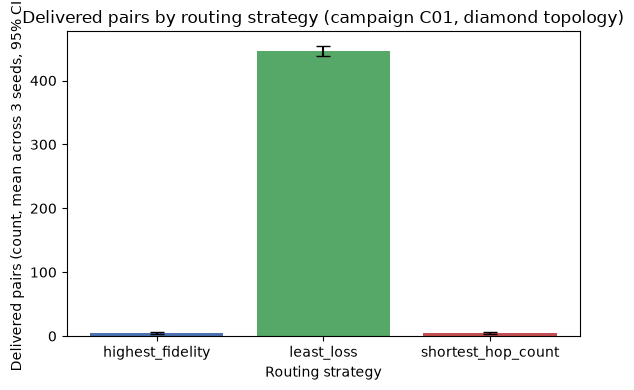

saved: ..\results\figures\article\A01_delivered_pairs_by_strategy.pdf


In [4]:
delivered = aggregated_df[aggregated_df["metric"] == "delivered_pairs"].set_index("routing_strategy")

fig, ax = plt.subplots(figsize=(6, 4))
strategies = delivered.index.tolist()
means = delivered["mean"]
errors = [
    [means[s] - delivered.loc[s, "ci95_low"] if pd.notna(delivered.loc[s, "ci95_low"]) else 0 for s in strategies],
    [delivered.loc[s, "ci95_high"] - means[s] if pd.notna(delivered.loc[s, "ci95_high"]) else 0 for s in strategies],
]
ax.bar(strategies, means, yerr=errors, capsize=5, color=["#4C72B0", "#55A868", "#C44E52"])
ax.set_ylabel("Delivered pairs (count, mean across 3 seeds, 95% CI)")
ax.set_xlabel("Routing strategy")
ax.set_title("Delivered pairs by routing strategy (campaign C01, diamond topology)")
fig.tight_layout()
pdf_path, png_path = save_figure(fig, "A01_delivered_pairs_by_strategy", directory=FIGURES_DIR)
plt.show()
print(f"saved: {pdf_path}")


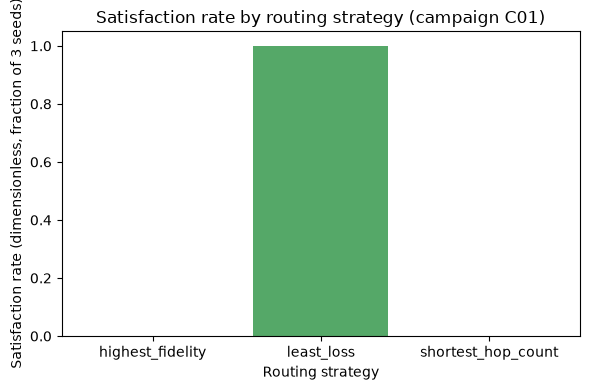

In [5]:
satisfaction = aggregated_df.drop_duplicates("routing_strategy").set_index("routing_strategy")["satisfaction_rate"]

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(satisfaction.index, satisfaction.values, color=["#4C72B0", "#55A868", "#C44E52"])
ax.set_ylabel("Satisfaction rate (dimensionless, fraction of 3 seeds)")
ax.set_xlabel("Routing strategy")
ax.set_ylim(0, 1.05)
ax.set_title("Satisfaction rate by routing strategy (campaign C01)")
fig.tight_layout()
save_figure(fig, "A01_satisfaction_rate_by_strategy", directory=FIGURES_DIR)
plt.show()


In [6]:
summary_table = aggregated_df[aggregated_df["metric"] == "delivered_pairs"][
    ["routing_strategy", "n_valid", "mean", "std", "ci95_low", "ci95_high", "satisfaction_rate", "violation_rate"]
].rename(columns={"mean": "mean_delivered_pairs", "std": "std_delivered_pairs"})
save_table(summary_table, "A01_routing_strategy_summary", directory=TABLES_DIR)
summary_table


,routing_strategy,n_valid,mean_delivered_pairs,std_delivered_pairs,ci95_low,ci95_high,satisfaction_rate,violation_rate
0,highest_fidelity,3,4.333333,0.57735,2.899116,5.767551,0.0,1.0
4,least_loss,3,446.333333,3.21455,438.347948,454.318719,1.0,0.0
8,shortest_hop_count,3,4.333333,0.57735,2.899116,5.767551,0.0,1.0


In [7]:
assert set(trials_df["routing_strategy"].unique()) == {"shortest_hop_count", "least_loss", "highest_fidelity"}
assert (trials_df["seed"].value_counts() == 3).all(), "each seed should appear exactly once per strategy"
least_loss_route = trials_df[trials_df["routing_strategy"] == "least_loss"]["route"].unique()
shortest_route = trials_df[trials_df["routing_strategy"] == "shortest_hop_count"]["route"].unique()
assert list(least_loss_route) != list(shortest_route), "least_loss must pick a genuinely different route than shortest_hop_count"
print("Confirmed: LeastLossRouting picks a different route than ShortestHopCountRouting/HighestFidelityRouting on this topology.")


Confirmed: LeastLossRouting picks a different route than ShortestHopCountRouting/HighestFidelityRouting on this topology.


## Interpretação
`ShortestHopCountRouting` e `HighestFidelityRouting` escolhem consistentemente
a rota de 2 saltos (`bad`), cuja alta atenuação limita o throughput e
resulta em `VIOLATED` nas 3 seeds. `LeastLossRouting` escolhe o desvio de
3 saltos (`good1`/`good2`), com perda óptica muito menor, entregando
dezenas de vezes mais pares e satisfazendo o intent nas 3 seeds. A escolha
de rota é determinística (não varia com a seed); o que varia entre seeds é
apenas o resultado físico observado ao longo da rota escolhida.

## Limitações
- `n=3` seeds por estratégia: suficiente para confirmar que a divergência
  não é uma coincidência de seed única, mas não sustenta um teste de
  hipótese formal (ver `docs/campaign_architecture.md`, seção 10).
- Esta comparação é específica da topologia em diamante - não generaliza
  automaticamente para outras topologias sem verificação (ver
  `C01_routing_strategy.yaml`'s description sobre por que atenuação não é
  varrida aqui).

## Conclusão
As três estratégias de roteamento comparadas com dados reais e persistidos:
`LeastLossRouting` diverge genuinamente das outras duas nesta topologia,
entregando muito mais pares e satisfazendo o intent onde as demais violam.
